In [1]:
try:
    import numpy as np
    import matplotlib as mpl
    import matplotlib.pyplot as plt
    import matplotlib.ticker as ticker
    import matplotlib.gridspec as gridspec
except ImportError as e:
    print(f"Error importing libraries: {e}")
    print("Matplotlib and NumPy are required to generate the plots.")

try:
    import scienceplots
    plt.style.use(['science', 'notebook'])
except ImportError:
    print("SciencePlots is not installed. Using default Matplotlib style (plots will look different).")

from pathlib import Path

In [2]:
root = Path.cwd() / "../.."
iceIh_path = root / "data" / "iceIh"

if iceIh_path.exists():
    iceIh_10perc_data = np.load(root / "data" / "iceIh" / "iceIh_10perc_vdos.npy", allow_pickle=True).item()
else:
    raise FileNotFoundError(f"Data directory {iceIh_path} does not exist. Please ensure the data files are in the correct location.")

In [3]:
vdos_norm = iceIh_10perc_data['vdos_norm']
vdos_exc = iceIh_10perc_data['vdos_exc']
delta_Omega_norm = iceIh_10perc_data['delta_Omega_norm']
delta_Omega_exc = iceIh_10perc_data['delta_Omega_exc']
I_norm = iceIh_10perc_data['I_norm']
I_exc = iceIh_10perc_data['I_exc']
dI_dt_norm = iceIh_10perc_data['dI_dt_norm']
dI_dt_exc = iceIh_10perc_data['dI_dt_exc']
Omega_mean_norm = iceIh_10perc_data['Omega_mean_norm']
Omega_mean_exc = iceIh_10perc_data['Omega_mean_exc']

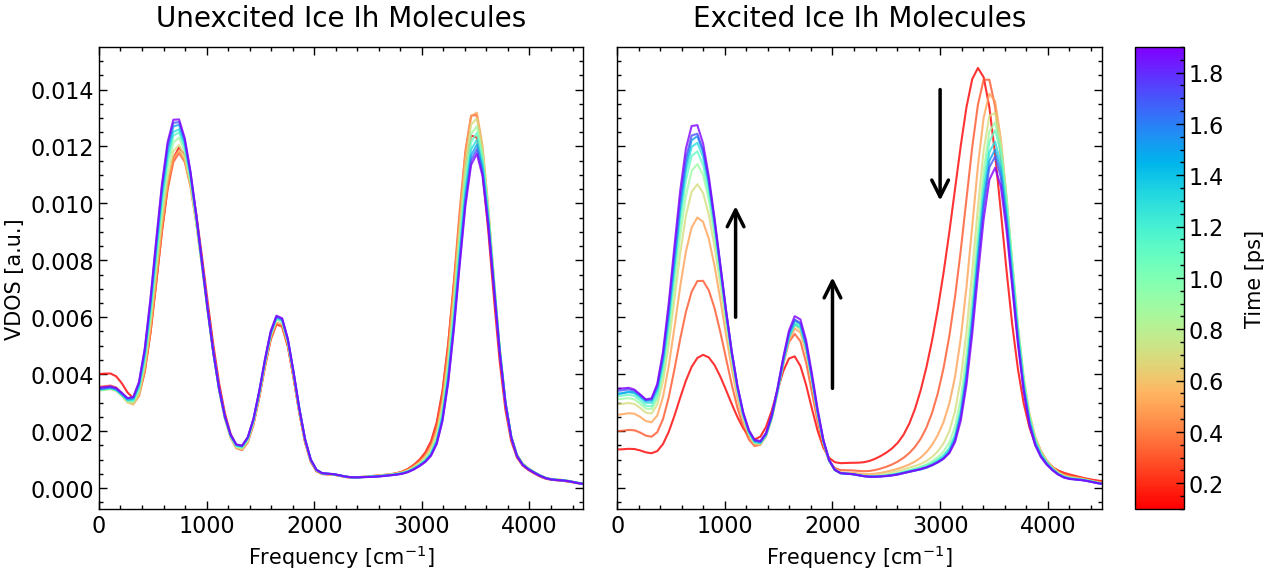

In [4]:
M = 10
E = 1
cmap = plt.get_cmap("tab10")
arrow_length = 0.004

time_indices = [1, 3, 5, 7, 9, 11, 13, 15, 17, 19]
num_lines = len(time_indices)
cmap = plt.get_cmap('rainbow_r')
norm = mpl.colors.Normalize(vmin=0, vmax=num_lines - 1)
color_array = cmap(np.linspace(0, 1, num_lines))
colorbar_label = 't (ps)'
label_fontsize = 15

fig = plt.figure(figsize=(14, 6))

gs = gridspec.GridSpec(1, 3, figure=fig,
                       width_ratios=[1, 1, 0.1],
                       wspace=0.1)

ax_bl = fig.add_subplot(gs[0, 0])
ax_br = fig.add_subplot(gs[0, 1], sharey=ax_bl)
cax = fig.add_subplot(gs[0, 2])

for i, time_idx in enumerate(time_indices):
    time_ps = time_idx * 0.1
    ax_bl.plot(vdos_norm[0][time_idx], vdos_norm[1][time_idx], 
              color=color_array[i], alpha=0.8, linewidth=1.5,
              label=f'{time_ps:.1f} ps' if i % 2 == 0 else "")

ax_bl.set_xlabel('Frequency [cm$^{-1}$]', fontsize=label_fontsize)
ax_bl.set_ylabel('VDOS [a.u.]', fontsize=label_fontsize)
ax_bl.set_xlim(0, 4500)

for i, time_idx in enumerate(time_indices):
    time_ps = time_idx * 0.1
    ax_br.plot(vdos_exc[0][time_idx], vdos_exc[1][time_idx], 
              color=color_array[i], alpha=0.8, linewidth=1.5)

ax_br.set_xlabel('Frequency [cm$^{-1}$]', fontsize=label_fontsize)
ax_br.set_xlim(0, 4500)
ax_br.tick_params(axis='y', labelleft=False)

ax_br.annotate(
    '',  # niente testo
    xy=(1100, 0.01),                
    xytext=(1100, 0.01 - arrow_length),    
    arrowprops=dict(
        arrowstyle='->',
        lw=2.5,
        mutation_scale=30,
        shrinkA=0,
        shrinkB=2,
        connectionstyle="angle3,angleA=0,angleB=90",
        color='k',
    )
)
ax_br.annotate(
    '',  # niente testo
    xy=(2000, 0.0075),                
    xytext=(2000, 0.0075 - arrow_length),    
    arrowprops=dict(
        arrowstyle='->',
        lw=2.5,
        mutation_scale=30,
        shrinkA=0,
        shrinkB=2,
        connectionstyle="angle3,angleA=0,angleB=90",
        color='k',
    )
)
ax_br.annotate(
    '',
    xy=(3000, 0.0100),                
    xytext=(3000, 0.0100 + arrow_length),    
    arrowprops=dict(
        arrowstyle='->',
        lw=2.5,
        mutation_scale=30,
        shrinkA=0,
        shrinkB=2,
        connectionstyle="angle3,angleA=0,angleB=90",
        color='k',
    )
)

ax_bl.set_title('Unexcited Ice Ih Molecules', fontsize=20, pad=15)
ax_br.set_title('Excited Ice Ih Molecules', fontsize=20, pad=15)


time_values = [time_indices[i] * 0.1 for i in range(num_lines)]
sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(vmin=min(time_values), vmax=max(time_values)), cmap=cmap)
sm.set_array([])
cbar = fig.colorbar(sm, cax=cax, orientation='vertical')
cbar.set_label('Time [ps]', fontsize=label_fontsize, labelpad=15)

plt.savefig(root / 'plots' / 'iceIh' / 'iceIh_10perc_vdos.png', dpi=300)
plt.show()

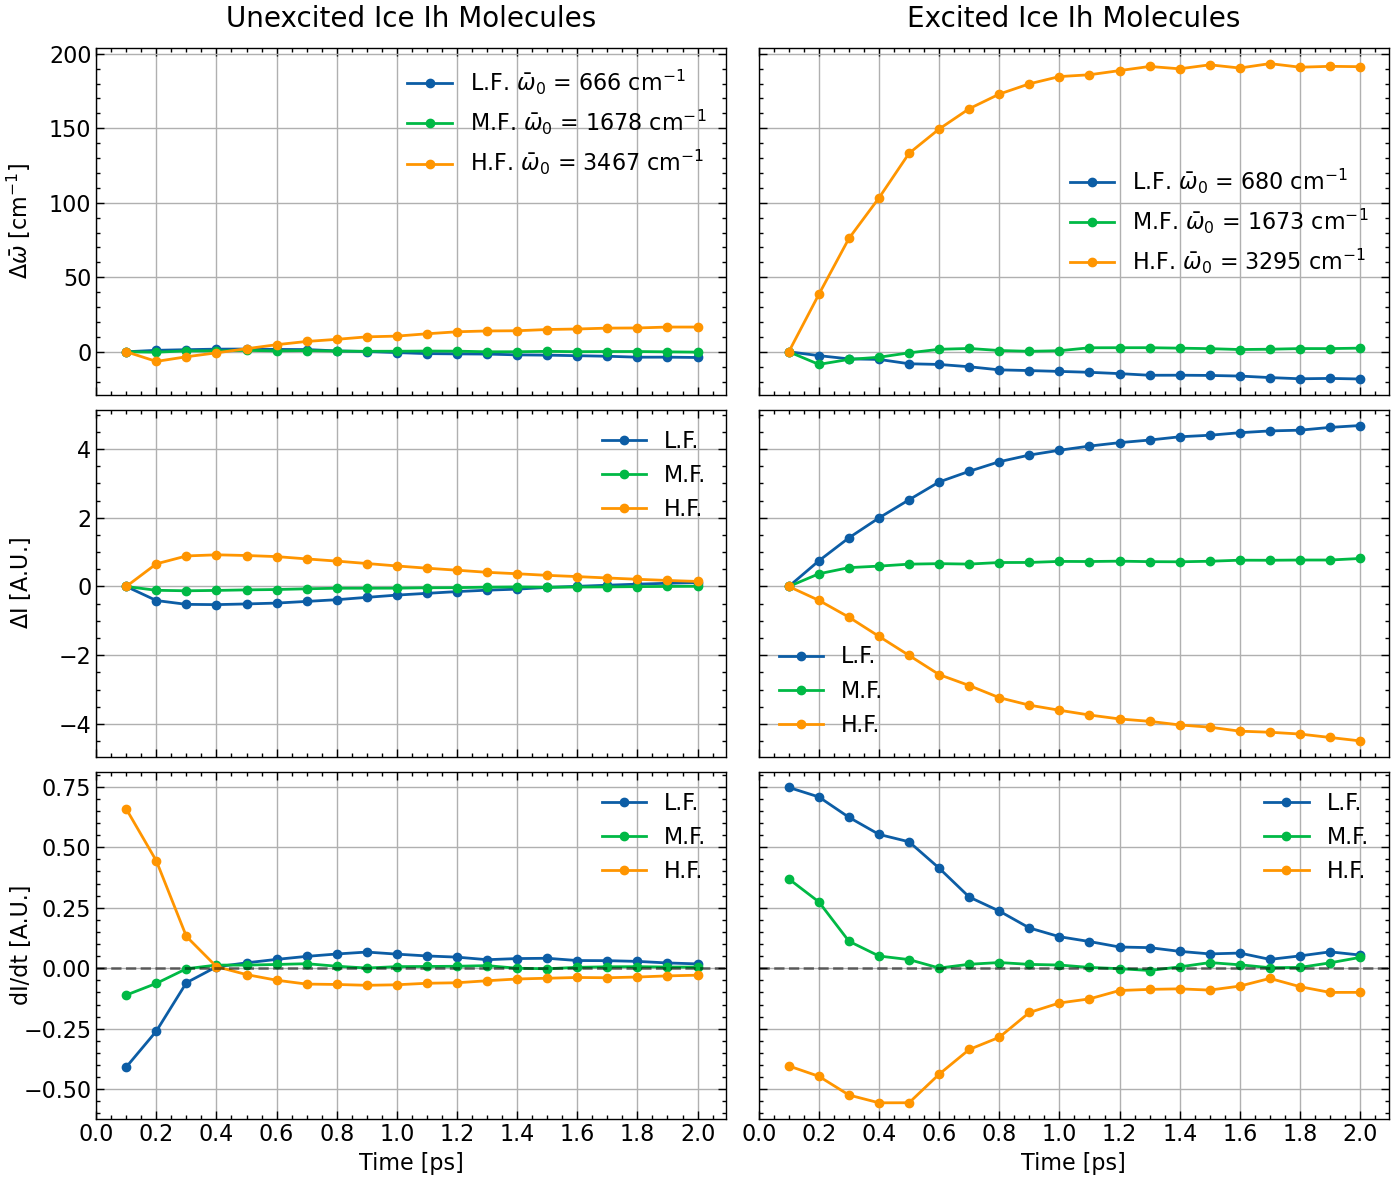

In [5]:
fig, axs = plt.subplots(3, 2, figsize=(14, 12), sharex='col', sharey='row')

ax0 = axs[0, 0]
ax0.plot(delta_Omega_norm[0], delta_Omega_norm[1], 'o-', color='C0', label=f'L.F. $\\bar \\omega_{{0}}$ = {Omega_mean_norm[0]:.0f} cm$^{{-1}}$')
ax0.plot(delta_Omega_norm[0], delta_Omega_norm[2], 'o-', color='C1', label=f'M.F. $\\bar \\omega_{{0}}$ = {Omega_mean_norm[1]:.0f} cm$^{{-1}}$')
ax0.plot(delta_Omega_norm[0], delta_Omega_norm[3], 'o-', color='C2', label=f'H.F. $\\bar \\omega_{{0}}$ = {Omega_mean_norm[2]:.0f} cm$^{{-1}}$')
ax0.set_ylabel('$\\Delta \\bar{\\omega}$ [cm$^{-1}$]')
ax0.legend()
ax0.grid(True)

ax1 = axs[1, 0]
ax1.plot(I_norm[0], I_norm[1], 'o-', color='C0', label=f'L.F.')
ax1.plot(I_norm[0], I_norm[2], 'o-', color='C1', label=f'M.F.')
ax1.plot(I_norm[0], I_norm[3], 'o-', color='C2', label=f'H.F.')
ax1.set_ylabel('$\\Delta$I [A.U.]')
ax1.legend()
ax1.grid(True)

ax2 = axs[2, 0]
ax2.plot(dI_dt_norm[0], dI_dt_norm[1], 'o-', color='C0', label=f'L.F.')
ax2.plot(dI_dt_norm[0], dI_dt_norm[2], 'o-', color='C1', label=f'M.F.')
ax2.plot(dI_dt_norm[0], dI_dt_norm[3], 'o-', color='C2', label=f'H.F.')
ax2.set_ylabel('dI/dt [A.U.]')
ax2.set_xlabel('Time [ps]')
ax2.legend()
ax2.grid(True)
ax2.axhline(y=0, color='k', linestyle='--', alpha=0.5)

ax3 = axs[0, 1]
ax3.plot(delta_Omega_exc[0], delta_Omega_exc[1], 'o-', color='C0', label=f'L.F. $\\bar \\omega_{{0}}$ = {Omega_mean_exc[0]:.0f} cm$^{{-1}}$')
ax3.plot(delta_Omega_exc[0], delta_Omega_exc[2], 'o-', color='C1', label=f'M.F. $\\bar \\omega_{{0}}$ = {Omega_mean_exc[1]:.0f} cm$^{{-1}}$')
ax3.plot(delta_Omega_exc[0], delta_Omega_exc[3], 'o-', color='C2', label=f'H.F. $\\bar \\omega_{{0}}$ = {Omega_mean_exc[2]:.0f} cm$^{{-1}}$')
ax3.legend(loc='center right')
ax3.grid(True)

ax4 = axs[1, 1]
ax4.plot(I_exc[0], I_exc[1], 'o-', label=f'L.F.')
ax4.plot(I_exc[0], I_exc[2], 'o-', label=f'M.F.')
ax4.plot(I_exc[0], I_exc[3], 'o-', label=f'H.F.')
ax4.legend()
ax4.grid(True)

ax5 = axs[2, 1]
ax5.plot(dI_dt_exc[0], dI_dt_exc[1], 'o-', label=f'L.F.')
ax5.plot(dI_dt_exc[0], dI_dt_exc[2], 'o-', label=f'M.F.')
ax5.plot(dI_dt_exc[0], dI_dt_exc[3], 'o-', label=f'H.F.')
ax5.set_xlabel('Time [ps]')
ax5.legend()
ax5.grid(True)
ax5.axhline(y=0, color='k', linestyle='--', alpha=0.5)

for col in range(3):
    for row in range(2):
        axs[col, row].set_xticks(np.arange(0, len(delta_Omega_norm[0])+1, 2)*0.1)

for ax in axs.flat:
    ax.yaxis.set_label_coords(-0.1, 0.5)

ax0.set_title('Unexcited Ice Ih Molecules', fontsize=20, pad=15)
ax3.set_title('Excited Ice Ih Molecules', fontsize=20, pad=15)

fig.tight_layout()
plt.savefig(root / 'plots' / 'iceIh' / 'iceIh_10perc_vdos_peaks.png', dpi=300)
plt.show()